# K-Means Clustering: Lusaka Securities Exchange (LuSE)

In this project, we investigate whether K-means clustering can be used as a practical and meaningful method for constructing stock baskets on the Lusaka Securities Exchange (LuSE). The central objective is to determine whether listed equities can be systematically grouped based on similar risk, return and market exposure characteristics, and whether these baskets (or combinations of them) yield high but stable returns using only information derived from historical price data.

Given the relatively small size, lower liquidity, and limited analyst coverage of the LuSE compared to developed markets, traditional portfolio construction approaches such as sector-based allocation or subjective stock selection may be suboptimal or difficult to apply consistently. An unsupervised learning approach such as K-means offers a simple, data-driven alternative, allowing stock groupings to emerge naturally from observed statistical behaviour rather than predefined classifications.

The clustering is performed using return-based features (mean returns, volatility, downside risk, drawdowns, and risk-adjusted performance measures) alongside systematic risk exposure, measured by beta relative to the LuSE All Share Index. By doing so, the analysis assesses whether K-means can identify coherent clusters such as defensive stocks, high-volatility growth stocks, or market-tracking equities.

Ultimately, the study evaluates the suitability of K-means clustering as a foundation for basket-based investing, risk diversification and index-like portfolio construction within an emerging and less efficient market context like the LuSE.

## Data Preparation and Library Import


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
sns.set_style('whitegrid')
idx = pd.IndexSlice
plt.style.use("seaborn-v0_8")
sns.set_theme()

The combined dataset containing historical price information for all listed securities is loaded from an external Excel file.<br>
The data is then cleaned by enforcing correct date formats and sorting observations chronologically for each company to ensure accurate analysis. Initial exploratory checks are performed to inspect the structure, summary statistics, and coverage of the data, confirming data integrity and consistency before further processing.

In [2]:
file_path = "combined_market_data.xlsx"  # Change this according your data source
df = pd.read_excel(file_path)

# Ensure correct data types
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Company','Date']).reset_index(drop=True)
df.head()

,Date,Company,Open,High,Low,Close,Volume
0,2015-10-01,AECI MINING EXPLOSIVES,6.84,6.84,6.84,6.84,11163
1,2015-10-12,AECI MINING EXPLOSIVES,6.85,6.85,6.85,6.85,3850
2,2015-10-20,AECI MINING EXPLOSIVES,6.85,6.85,6.85,6.85,13696
3,2015-10-26,AECI MINING EXPLOSIVES,6.85,6.85,6.85,6.85,500
4,2015-10-27,AECI MINING EXPLOSIVES,6.85,6.85,6.85,6.85,8000


We inspect the dataset to see if everything is aligned.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58887 entries, 0 to 58886
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     58887 non-null  datetime64[ns]
 1   Company  58887 non-null  object        
 2   Open     58887 non-null  float64       
 3   High     58887 non-null  float64       
 4   Low      58887 non-null  float64       
 5   Close    58887 non-null  float64       
 6   Volume   58887 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 3.1+ MB


In [4]:
df.describe()

,Date,Open,High,Low,Close,Volume
count,58887,58887.000000,58887.000000,58887.000000,58887.000000,5.888700e+04
mean,2021-03-25 01:20:47.684548096,36.611579,30.212718,31.341162,362.160241,1.837748e+05
min,2015-07-29 00:00:00,0.000000,0.000000,0.000000,0.070000,0.000000e+00
25%,2018-11-10 12:00:00,1.800000,0.000000,0.000000,1.980000,0.000000e+00
50%,2021-03-17 00:00:00,3.000000,0.000000,1.330000,3.640000,0.000000e+00
75%,2023-08-11 00:00:00,12.000000,2.500000,4.620000,13.930000,2.265000e+02
max,2026-02-03 00:00:00,5859.450000,5859.450000,5859.450000,26370.020000,6.582469e+08
std,NaN,361.438883,361.706243,361.541120,1987.107791,7.745698e+06


In [5]:
df['Company'].value_counts()

Company
LUSE ALL SHARE INDEX                                 2599
COPPERBELT ENERGY CORPORATION                        2517
CHILANGA CEMENT                                      2447
STANDARD CHARTERED BANK ZAMBIA                       2441
MADISON FINANCIAL SERVICES                           2430
ZAMBIA NATIONAL COMMERCIAL BANK                      2396
REAL ESTATE INVESTMENTS ZAMBIA                       2388
ZAMBIAN BREWERIES                                    2380
ZAMBIA SUGAR                                         2379
AECI MINING EXPLOSIVES                               2378
ZAMBEEF PRODUCTS                                     2375
PUMA ENERGY ZAMBIA                                   2372
AIRTEL NETWORKS ZAMBIA                               2369
NATIONAL BREWERIES                                   2368
ZAMBIA BATA SHOE                                     2356
BRITISH AMERICAN TOBACCO ZAMBIA                      2356
METAL FABRICATORS OF ZAMBIA (ZAMEFA)                 2350
SHOPRI

In [6]:
# . Handle Missing Values
print(df.isna().sum())  # check missing values
df = df.drop_duplicates()

Date       0
Company    0
Open       0
High       0
Low        0
Close      0
Volume     0
dtype: int64


In [7]:
df["Company"].unique()

array(['AECI MINING EXPLOSIVES', 'AIRTEL NETWORKS ZAMBIA',
       'BRITISH AMERICAN TOBACCO ZAMBIA', 'CAVMONT CAPITAL HOLDINGS',
       'CEC AFRICA INVESTMENT', 'CHILANGA CEMENT',
       'COPPERBELT ENERGY CORPORATION', 'DOT COM ZAMBIA',
       'EIZ PROPERTIES', 'FIRST QUANTUM MINERALS', 'INVESTRUST BANK',
       'LUSE ALL SHARE INDEX', 'MADISON FINANCIAL SERVICES',
       'METAL FABRICATORS OF ZAMBIA (ZAMEFA)', 'NATIONAL BREWERIES',
       'PAMODZI HOTELS', 'PRIMA REINSURANCE', 'PUMA ENERGY ZAMBIA',
       'REAL ESTATE INVESTMENTS ZAMBIA', 'SHOPRITE HOLDINGS',
       'STANDARD CHARTERED BANK ZAMBIA', 'ZAMBEEF PRODUCTS',
       'ZAMBIA BATA SHOE',
       'ZAMBIA FORESTRY AND FOREST INDUSTRIES CORPORATION',
       'ZAMBIA NATIONAL COMMERCIAL BANK', 'ZAMBIA SUGAR',
       'ZAMBIAN BREWERIES', 'ZCCM INVESTMENT HOLDINGS'], dtype=object)

The dataset is missing tickers so we add them here for easier stock identification

In [8]:
#Insert Ticker for companies
name_to_ticker = {
    "AECI MINING EXPLOSIVES": "AECI",
    "PRIMA REINSURANCE": "ZMRE",
    "ZAMBIA SUGAR": "ZSUG",
    "MADISON FINANCIAL SERVICES": "MAFS",
    "ZAMBEEF PRODUCTS": "ZMBF",
    "METAL FABRICATORS OF ZAMBIA (ZAMEFA)": "ZMFA",
    "COPPERBELT ENERGY CORPORATION": "CECZ",
    "AIRTEL NETWORKS ZAMBIA": "ATEL",
    "ZAMBIA NATIONAL COMMERCIAL BANK": "ZNCO",
    "NATIONAL BREWERIES": "NATB",
    "ZAMBIAN BREWERIES": "ZABR",
    "PAMODZI HOTELS": "PMDZ",
    "ZAMBIA FORESTRY AND FOREST INDUSTRIES CORPORATION": "ZFCO",
    "CHILANGA CEMENT": "CHIL",
    "PUMA ENERGY ZAMBIA": "PUMA",
    "CEC AFRICA INVESTMENT": "CCAF",
    "REAL ESTATE INVESTMENTS ZAMBIA": "REIZ",
    "ZCCM INVESTMENT HOLDINGS": "ZCCM",
    "ZAMBIA BATA SHOE": "BATA",
    "SHOPRITE HOLDINGS": "SHOP",
    "STANDARD CHARTERED BANK ZAMBIA": "SCBL",
    "BRITISH AMERICAN TOBACCO ZAMBIA": "BATZ",
    "EIZ PROPERTIES": "EIZP",
    "DOT COM ZAMBIA": "DCZ",
    "LUSE ALL SHARE INDEX": "LASI"
}

# create a new ticker column
df["Ticker"] = df["Company"].map(name_to_ticker)

# optional sanity check
unmatched = df.loc[df["Ticker"].isna(), "Company"].unique()
if len(unmatched) > 0:
    print("Unmatched companies:", unmatched)


Unmatched companies: ['CAVMONT CAPITAL HOLDINGS' 'FIRST QUANTUM MINERALS' 'INVESTRUST BANK']


The dataset contains companies that were delisted from the exchange.<br>
We need to group them and delete from the dataset

In [9]:
#Remove delisted companies
delisted_companies = [
    "INVESTRUST BANK",
    "FIRST QUANTUM MINERALS",
    "CAVMONT CAPITAL HOLDINGS"
]
df[df["Company"].isin(delisted_companies)]

,Date,Company,Open,High,Low,Close,Volume,Ticker
7103,2015-09-08,CAVMONT CAPITAL HOLDINGS,2.0,2.0,2.0,2.0,240,NaN
7104,2015-11-04,CAVMONT CAPITAL HOLDINGS,2.0,2.0,2.0,2.0,528,NaN
7105,2015-11-05,CAVMONT CAPITAL HOLDINGS,2.0,2.0,2.0,2.0,23,NaN
7106,2015-11-16,CAVMONT CAPITAL HOLDINGS,2.0,2.0,2.0,2.0,60000,NaN
7107,2015-11-18,CAVMONT CAPITAL HOLDINGS,2.0,2.0,2.0,2.0,175000,NaN
...,...,...,...,...,...,...,...,...
19202,2024-04-22,INVESTRUST BANK,25.0,0.0,0.0,25.0,0,NaN
19203,2024-04-23,INVESTRUST BANK,25.0,0.0,0.0,25.0,0,NaN
19204,2024-04-24,INVESTRUST BANK,25.0,0.0,0.0,25.0,0,NaN
19205,2024-04-25,INVESTRUST BANK,25.0,0.0,0.0,25.0,0,NaN


In [10]:
df = df[~df["Company"].isin(delisted_companies)]

The LuSE All Share Index is separated from individual stock data to allow it to be treated as the market benchmark. <br>
This separation enables the calculation of market returns and systematic risk measures, such as beta, while ensuring that the index itself is excluded from the clustering process applied to individual equities.

In [11]:
# Separate market index from individual stocks
market_mask = df["Company"] == "LUSE ALL SHARE INDEX"
market_df = df.loc[market_mask].copy()
stocks_df = df.loc[~market_mask].copy()


Before feature construction, the stock dataset is checked for missing values and duplicate records. <br> 
Duplicate observations are removed to prevent bias in return and risk calculations.<br> 
Date fields for both the stock data and the market index are explicitly converted to datetime format to ensure proper alignment and reliable time-series operations in subsequent analysis.


In [12]:
# Check and handle missing values
print("Missing values:\n", stocks_df.isna().sum())
stocks_df = stocks_df.drop_duplicates()

# Ensure datetime format
stocks_df['Date'] = pd.to_datetime(stocks_df['Date'])
market_df['Date'] = pd.to_datetime(market_df['Date'])

Missing values:
 Date       0
Company    0
Open       0
High       0
Low        0
Close      0
Volume     0
Ticker     0
dtype: int64


In [13]:
#Inspect LASI dataframe
market_df.head()

,Date,Company,Open,High,Low,Close,Volume,Ticker
19207,2015-07-29,LUSE ALL SHARE INDEX,5846.54,5846.54,5846.54,5846.54,960059,LASI
19208,2015-07-30,LUSE ALL SHARE INDEX,5847.31,5847.31,5847.31,5847.31,23567,LASI
19209,2015-07-31,LUSE ALL SHARE INDEX,5847.31,5847.31,5847.31,5847.31,2300,LASI
19210,2015-08-04,LUSE ALL SHARE INDEX,5843.19,5843.19,5843.19,5843.19,43071,LASI
19211,2015-08-05,LUSE ALL SHARE INDEX,5839.67,5839.67,5839.67,5839.67,70944,LASI


In [14]:
#Convert market_df index to datetime
market_df["Date"] = pd.to_datetime(market_df["Date"]) 
market_df = market_df.set_index("Date").sort_index()
market_df.head()

,Company,Open,High,Low,Close,Volume,Ticker
Date,,,,,,,
2015-07-29,LUSE ALL SHARE INDEX,5846.54,5846.54,5846.54,5846.54,960059,LASI
2015-07-30,LUSE ALL SHARE INDEX,5847.31,5847.31,5847.31,5847.31,23567,LASI
2015-07-31,LUSE ALL SHARE INDEX,5847.31,5847.31,5847.31,5847.31,2300,LASI
2015-08-04,LUSE ALL SHARE INDEX,5843.19,5843.19,5843.19,5843.19,43071,LASI
2015-08-05,LUSE ALL SHARE INDEX,5839.67,5839.67,5839.67,5839.67,70944,LASI


In [15]:
market_df.value_counts

<bound method DataFrame.value_counts of                          Company     Open     High      Low     Close  \
Date                                                                    
2015-07-29  LUSE ALL SHARE INDEX  5846.54  5846.54  5846.54   5846.54   
2015-07-30  LUSE ALL SHARE INDEX  5847.31  5847.31  5847.31   5847.31   
2015-07-31  LUSE ALL SHARE INDEX  5847.31  5847.31  5847.31   5847.31   
2015-08-04  LUSE ALL SHARE INDEX  5843.19  5843.19  5843.19   5843.19   
2015-08-05  LUSE ALL SHARE INDEX  5839.67  5839.67  5839.67   5839.67   
...                          ...      ...      ...      ...       ...   
2026-01-28  LUSE ALL SHARE INDEX     0.00     0.00     0.00  26166.13   
2026-01-29  LUSE ALL SHARE INDEX     0.00     0.00     0.00  26156.81   
2026-01-30  LUSE ALL SHARE INDEX     0.00     0.00     0.00  26227.36   
2026-02-02  LUSE ALL SHARE INDEX     0.00     0.00     0.00  26199.65   
2026-02-03  LUSE ALL SHARE INDEX     0.00     0.00     0.00  26194.40   

          

## Create Returns Matrix

This part takes the stock price data (stocks_df) and reshapes it into a matrix format where each row is a date, each column is a stock (identified by Ticker), and the values are the closing prices for that stock on that day. This is done using pivoting, which is a common way to organize time series data for multiple assets.

In [16]:
# Pivot stock prices to wide format
prices = (
    stocks_df[['Date', 'Ticker', 'Close']]
    .pivot(index='Date', columns='Ticker', values='Close')
    .sort_index()
)
prices.head()

Ticker,AECI,ATEL,BATA,BATZ,CCAF,CECZ,CHIL,DCZ,EIZP,MAFS,...,SCBL,SHOP,ZABR,ZCCM,ZFCO,ZMBF,ZMFA,ZMRE,ZNCO,ZSUG
Date,,,,,,,,,,,,,,,,,,,,,
2015-08-17,NaN,33.0,NaN,NaN,NaN,0.63,24.0,NaN,NaN,NaN,...,1.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-08-18,NaN,33.0,NaN,NaN,NaN,0.63,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.1,NaN,NaN,NaN,NaN
2015-08-19,NaN,NaN,2.5,NaN,NaN,0.63,NaN,NaN,NaN,3.5,...,NaN,NaN,NaN,NaN,NaN,3.1,NaN,NaN,NaN,NaN
2015-08-20,NaN,NaN,2.5,NaN,NaN,0.63,24.0,NaN,NaN,3.5,...,1.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0
2015-08-21,NaN,NaN,NaN,NaN,NaN,0.65,24.0,NaN,NaN,NaN,...,1.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This step converts price data into **percentage returns**, capturing the relative daily change in stock prices. <br> 

$$ 
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

Similarly, the market index is aligned by date and transformed into market returns (market_ret), providing a benchmark for later analyses such as beta calculation or risk adjustment.


In [17]:
market_df.head()

,Company,Open,High,Low,Close,Volume,Ticker
Date,,,,,,,
2015-07-29,LUSE ALL SHARE INDEX,5846.54,5846.54,5846.54,5846.54,960059,LASI
2015-07-30,LUSE ALL SHARE INDEX,5847.31,5847.31,5847.31,5847.31,23567,LASI
2015-07-31,LUSE ALL SHARE INDEX,5847.31,5847.31,5847.31,5847.31,2300,LASI
2015-08-04,LUSE ALL SHARE INDEX,5843.19,5843.19,5843.19,5843.19,43071,LASI
2015-08-05,LUSE ALL SHARE INDEX,5839.67,5839.67,5839.67,5839.67,70944,LASI


In [18]:
# Calculate returns
returns = prices.pct_change().dropna(how="all")

# Prepare market returns
market_ret = market_df["Close"].pct_change().dropna()
market_ret.name = "market"

C:\Users\Other User\AppData\Local\Temp\ipykernel_54824\1708032748.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna(how="all")


In [19]:
returns.head()

Ticker,AECI,ATEL,BATA,BATZ,CCAF,CECZ,CHIL,DCZ,EIZP,MAFS,...,SCBL,SHOP,ZABR,ZCCM,ZFCO,ZMBF,ZMFA,ZMRE,ZNCO,ZSUG
Date,,,,,,,,,,,,,,,,,,,,,
2015-08-18,NaN,0.0,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-08-19,NaN,0.0,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
2015-08-20,NaN,0.0,0.0,NaN,NaN,0.000000,0.0,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
2015-08-21,NaN,0.0,0.0,NaN,NaN,0.031746,0.0,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0
2015-08-24,NaN,0.0,0.0,NaN,NaN,0.000000,0.0,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0


In [20]:
market_ret.head()

Date
2015-07-30    0.000132
2015-07-31    0.000000
2015-08-04   -0.000705
2015-08-05   -0.000602
2015-08-06    0.003387
Name: market, dtype: float64

In [21]:
# Check the date formats and ranges
print("Returns index type:", type(returns.index))
print("Market returns index type:", type(market_ret.index))
print("\nReturns date range:")
print("First:", returns.index.min())
print("Last:", returns.index.max())
print("\nMarket returns date range:")
print("First:", market_ret.index.min())
print("Last:", market_ret.index.max())
print("\nSample returns dates:", returns.index[:5])
print("Sample market dates:", market_ret.index[:5])

Returns index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Market returns index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

Returns date range:
First: 2015-08-18 00:00:00
Last: 2026-02-03 00:00:00

Market returns date range:
First: 2015-07-30 00:00:00
Last: 2026-02-03 00:00:00

Sample returns dates: DatetimeIndex(['2015-08-18', '2015-08-19', '2015-08-20', '2015-08-21',
               '2015-08-24'],
              dtype='datetime64[ns]', name='Date', freq=None)
Sample market dates: DatetimeIndex(['2015-07-30', '2015-07-31', '2015-08-04', '2015-08-05',
               '2015-08-06'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [22]:
print(market_df.columns)

Index(['Company', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker'], dtype='object')


In [23]:
print(market_df.index.name)

Date


In [24]:
# Align dates between stocks and market
common_dates = returns.index.intersection(market_ret.index)
returns = returns.loc[common_dates]
market_ret = market_ret.loc[common_dates]

In [25]:
print("\nReturns date range:")
print("First:", returns.index.min())
print("Last:", returns.index.max())
print("\nMarket returns date range:")
print("First:", market_ret.index.min())
print("Last:", market_ret.index.max())


Returns date range:
First: 2015-08-18 00:00:00
Last: 2026-02-03 00:00:00

Market returns date range:
First: 2015-08-18 00:00:00
Last: 2026-02-03 00:00:00


## Feature Engineering

We extract risk and performance features from stock returns for clustering. We will use the following features:


1. **Maximum Drawdown (MDD)**  
   Measures the largest peak-to-trough decline:
   $$
   \text{MDD} = \min \left( \frac{C_t - \max(C_{1:t})}{\max(C_{1:t})} \right)
   $$ 
   where $$ C_t = \prod_{i=1}^{t} (1 + R_i) $$
is the cumulative return.

2. **Downside Volatility (Semi-Deviation)**  
   Captures volatility of negative returns relative to a threshold (risk-free rate $rf$):
   $$
   \sigma_\text{down} = \sqrt{t} \cdot \text{std}(\{ R_t \mid R_t < rf \})
   $$ 
   Annualized to compare across assets.

3. **Sharpe Ratio**  
   Measures risk-adjusted return using total volatility:
   $$
   \text{Sharpe} = \frac{t \cdot (\bar{R} - rf)}{\sqrt{t} \cdot \text{std}(R)}
   $$

4. **Sortino Ratio**  
   Similar to Sharpe but penalizes only downside volatility:
   $$
   \text{Sortino} = \frac{t \cdot (\bar{R} - rf)}{\sigma_\text{down}}
   $$

**Notes:**  
- $R_t$ = daily return at time t 
- $t$ = trading days in a year for annualization  
- $rf$ = risk-free rate (default 0 for simplicity)

In [26]:
# Calculate actual trading days per year from your data
def get_annualization_factor(returns_df):
    """
    Calculate the average number of trading days per year in the dataset
    """
    # Ensure index is datetime
    if not isinstance(returns_df.index, pd.DatetimeIndex):
        print("Converting index to datetime...")
        index = pd.to_datetime(returns_df.index)
    else:
        index = returns_df.index
    
    # Count trading days per year
    trading_days_per_year = index.to_series().groupby(index.year).size()
    
    # Get average
    avg_trading_days = trading_days_per_year.mean()
    
    print(f"\nTrading days per year:")
    print(trading_days_per_year)
    print(f"\nAverage trading days per year: {avg_trading_days:.1f}")
    
    return avg_trading_days

# Calculate from your data
TRADING_DAYS = get_annualization_factor(returns)


Trading days per year:
Date
2015     87
2016    233
2017    245
2018    246
2019    247
2020    248
2021    245
2022    246
2023    246
2024    248
2025    248
2026     23
Name: Date, dtype: int64

Average trading days per year: 213.5


In [27]:
#Feature functions 
def max_drawdown(returns_series):
    """Calculate maximum drawdown from a returns series"""
    cum_returns = (1 + returns_series).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    return drawdown.min()

def downside_vol(returns_series, rf=0, trading_days=TRADING_DAYS):
    """Calculate annualized downside volatility"""
    downside_returns = returns_series[returns_series < rf]
    return downside_returns.std() * np.sqrt(trading_days)

def sharpe_ratio(returns_series, rf=0, trading_days=TRADING_DAYS):
    """Calculate annualized Sharpe ratio"""
    excess_return = returns_series.mean() - rf
    return (excess_return * trading_days) / (returns_series.std() * np.sqrt(trading_days))

def sortino_ratio(returns_series, rf=0, trading_days=TRADING_DAYS):
    """Calculate annualized Sortino ratio"""
    excess_return = returns_series.mean() - rf
    return (excess_return * trading_days) / downside_vol(returns_series, rf, trading_days)

In [28]:
## Calculate features for each stock
features = pd.DataFrame(index=returns.columns)

features["mean_return"] = returns.mean() * TRADING_DAYS  # Annualized
features["volatility"] = returns.std() * np.sqrt(TRADING_DAYS)  # Annualized
features["downside_vol"] = returns.apply(lambda x: downside_vol(x, trading_days=TRADING_DAYS))
features["max_drawdown"] = returns.apply(max_drawdown)
features["sharpe"] = returns.apply(lambda x: sharpe_ratio(x, trading_days=TRADING_DAYS))
features["sortino"] = returns.apply(lambda x: sortino_ratio(x, trading_days=TRADING_DAYS))

C:\Users\Other User\AppData\Local\Temp\ipykernel_54824\3003401493.py:17: RuntimeWarning: invalid value encountered in scalar divide
  return (excess_return * trading_days) / (returns_series.std() * np.sqrt(trading_days))


## Beta 

We estimate each stock’s **systematic risk (beta)** using a market model regression. Beta measures how much a stock moves relative to the market. It is estimated using the single-factor market model:

$$
R_{i,t} = \alpha_i + \beta_i R_{m,t} + \varepsilon_{i,t}
$$

Under OLS, the estimated slope coefficient is:

$$
\beta_i = \frac{\operatorname{Cov}(R_i, R_m)}{\operatorname{Var}(R_m)}
$$

where:
- $R_i$ = stock returns  
- $R_m$ = market returns  

**Interpretation:**

- $\beta = 1$ → moves with market  
- $\beta > 1$ → more volatile than market
- $\beta < 1$ → less volatile / defensive


In [29]:
# Calculate beta for each stock
betas = {}
for ticker in returns.columns:
    stock_returns = returns[ticker].dropna()
    market_aligned = market_ret.loc[stock_returns.index]
    
    if len(stock_returns) > 20:  # Minimum observations
        X_reg = sm.add_constant(market_aligned)
        model = sm.OLS(stock_returns, X_reg).fit()
        betas[ticker] = model.params["market"]
    else:
        betas[ticker] = np.nan

features["beta"] = pd.Series(betas)


In [30]:
# Remove stocks with missing features
X = features.dropna()
print(f"\nFeatures calculated for {len(X)} stocks")
print(f"\nFeature summary:\n{X.describe()}")


Features calculated for 23 stocks

Feature summary:
       mean_return  volatility  downside_vol  max_drawdown     sharpe  \
count    23.000000   23.000000     23.000000     23.000000  23.000000   
mean      0.271903    0.325179      0.841575     -0.498133   0.650556   
std       0.683944    0.261694      0.432262      0.283593   1.194598   
min      -0.114001    0.115957      0.287716     -0.988333  -0.729078   
25%       0.042026    0.192799      0.579472     -0.739259   0.153599   
50%       0.132574    0.277461      0.765541     -0.550000   0.526241   
75%       0.222135    0.339561      1.068991     -0.244000   0.786761   
max       3.352497    1.397329      2.304726     -0.103182   5.719283   

         sortino       beta  
count  23.000000  23.000000  
mean    0.503341   0.337879  
std     1.354656   0.449366  
min    -0.080370  -0.127590  
25%     0.065014   0.029451  
50%     0.181135   0.177754  
75%     0.306282   0.562901  
max     6.601745   1.411115  


In [31]:
X.head()

,mean_return,volatility,downside_vol,max_drawdown,sharpe,sortino,beta
Ticker,,,,,,,
AECI,0.295810,0.318596,0.794785,-0.300444,0.928480,0.372189,0.220301
ATEL,0.141201,0.210328,0.615801,-0.564103,0.671336,0.229296,0.423634
BATA,0.116107,0.203267,0.640999,-0.200000,0.571207,0.181135,0.019516
BATZ,0.117169,0.277461,1.159445,-0.756098,0.422289,0.101056,0.220780
CCAF,0.103130,0.320989,0.786940,-0.763636,0.321289,0.131052,-0.126988


### Feature Summary Interpretation

After filtering for complete feature availability, 23 stocks remain for clustering.  
The summary statistics indicate substantial **heterogeneity in risk and performance**, which is desirable for K-Means.

- **Mean Returns:** Wide dispersion (−11% to 335%) suggests structurally different return profiles, likely driven by liquidity and firm size effects.
- **Volatility & Downside Volatility:** Downside risk exceeds total volatility for many stocks, reflecting asymmetric return distributions common in thinly traded markets.
- **Maximum Drawdown:** Deep drawdowns (median ≈ −55%) indicate significant tail risk and prolonged recovery periods.
- **Sharpe & Sortino Ratios:** Large spread and right-skewness imply that only a few stocks deliver strong risk-adjusted performance.
- **Beta:** Low median beta (≈ 0.18) suggests weak market co-movement, consistent with partial market segmentation and low index representativeness.

Overall, the feature set captures **both return potential and multiple dimensions of risk**, providing a suitable basis for unsupervised clustering.


# Determine Optimal Number of Clusters


Before clustering, all features are **standardized** to zero mean and unit variance to prevent variables with larger scales (e.g. volatility) from dominating distance calculations.

$$
X_{\text{scaled}} = \frac{X - \mu}{\sigma}
$$

The **Elbow Method** and **Silhouette Score** are then used to assess clustering quality across different values of \(K\):

- **WCSS (Within-Cluster Sum of Squares):**
$$
\text{WCSS} = \sum_{k=1}^{K} \sum_{i \in C_k} \lVert x_i - \mu_k \rVert^2
$$
Measures cluster compactness; diminishing reductions indicate an appropriate \(K\).

- **Silhouette Score:**
$$
s_i = \frac{b_i - a_i}{\max(a_i, b_i)}
$$
where $a_i$ is the average intra-cluster distance and $b_i$ the nearest-cluster distance.

Higher silhouette values indicate better-separated clusters.  
Together, these metrics balance **compactness** and **separation** when selecting the optimal number of clusters.


In [32]:
X.head()

,mean_return,volatility,downside_vol,max_drawdown,sharpe,sortino,beta
Ticker,,,,,,,
AECI,0.295810,0.318596,0.794785,-0.300444,0.928480,0.372189,0.220301
ATEL,0.141201,0.210328,0.615801,-0.564103,0.671336,0.229296,0.423634
BATA,0.116107,0.203267,0.640999,-0.200000,0.571207,0.181135,0.019516
BATZ,0.117169,0.277461,1.159445,-0.756098,0.422289,0.101056,0.220780
CCAF,0.103130,0.320989,0.786940,-0.763636,0.321289,0.131052,-0.126988


In [33]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))


c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

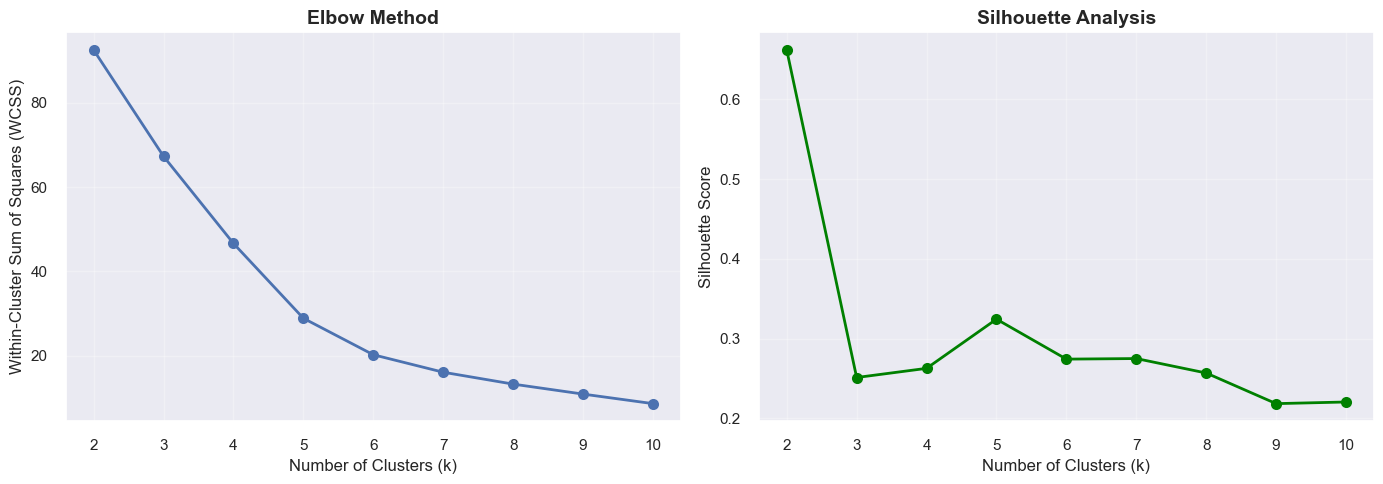

In [34]:
# Visualize both metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Elbow plot
ax1.plot(K_range, wcss, marker="o", linewidth=2, markersize=8)
ax1.set_xlabel("Number of Clusters (k)", fontsize=12)
ax1.set_ylabel("Within-Cluster Sum of Squares (WCSS)", fontsize=12)
ax1.set_title("Elbow Method", fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
# Silhouette plot
ax2.plot(K_range, silhouette_scores, marker="o", linewidth=2, markersize=8, color='green')
ax2.set_xlabel("Number of Clusters (k)", fontsize=12)
ax2.set_ylabel("Silhouette Score", fontsize=12)
ax2.set_title("Silhouette Analysis", fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# Print silhouette scores
print("\nSilhouette Scores:")
for k, score in zip(K_range, silhouette_scores):
    print(f"k={k}: {score:.3f}")


Silhouette Scores:
k=2: 0.662
k=3: 0.251
k=4: 0.263
k=5: 0.324
k=6: 0.274
k=7: 0.275
k=8: 0.257
k=9: 0.218
k=10: 0.220


k = 2 maximizes the silhouette score (0.662), which means:

- One cluster is very tight and well-separated

- The other cluster is far away in feature space

The fact that one cluster contains only 1 stock means:

- That stock is an extreme outlier across your engineered features

- K-Means is effectively separating “everything else” vs “this one very different stock”

So k = 2 is mathematically optimal but it is economically trivial.

Although \(k = 2\) yields the highest silhouette score, the resulting clustering produces a singleton cluster containing a single stock. This indicates the presence of a strong outlier rather than a meaningful segmentation of the universe.

To obtain economically interpretable groups, we prioritize solutions that balance statistical separation with sufficient cluster membership. Consequently, higher values of \(k\) are considered to capture heterogeneous risk–return profiles beyond simple outlier detection.

# Final Clustering


What k should we reasonably choose?

From the scores:

- k = 5 is the best non-trivial solution:

- Local maximum silhouette (0.324)

- Clear elbow around k = 4–6

- Likely produces multiple multi-stock clusters

In [36]:
# Choose optimal k (adjust based on elbow/silhouette analysis)
k_optimal = 5 

kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=20, max_iter=300)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add clusters to features dataframe
X["cluster"] = cluster_labels

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Other User\AppData\Local\Temp\ipykernel_54824\3989463109.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["cluster"] = cluster_labels


In [37]:
#Summary statistics by cluster
print(f"\n{'='*80}")
print(f"CLUSTER ANALYSIS (k={k_optimal})")
print(f"{'='*80}\n")

for cluster_id in sorted(X["cluster"].unique()):
    cluster_data = X[X["cluster"] == cluster_id]
    print(f"\n--- Cluster {cluster_id} ({len(cluster_data)} stocks) ---")
    print(f"Stocks: {', '.join(cluster_data.index.tolist())}")
    print(f"\nCharacteristics:")
    print(cluster_data.drop(columns="cluster").mean().to_string())
    print("\n")


CLUSTER ANALYSIS (k=5)


--- Cluster 0 (3 stocks) ---
Stocks: BATZ, NATB, REIZ

Characteristics:
mean_return    -0.011311
volatility      0.297530
downside_vol    1.627544
max_drawdown   -0.843452
sharpe         -0.129220
sortino         0.001529
beta            0.112646



--- Cluster 1 (1 stocks) ---
Stocks: DCZ

Characteristics:
mean_return     3.352497
volatility      0.586174
downside_vol    0.507820
max_drawdown   -0.164151
sharpe          5.719283
sortino         6.601745
beta           -0.127590



--- Cluster 2 (12 stocks) ---
Stocks: AECI, ATEL, BATA, CCAF, MAFS, PUMA, SHOP, ZCCM, ZFCO, ZMBF, ZMFA, ZMRE

Characteristics:
mean_return     0.116688
volatility      0.215909
downside_vol    0.742478
max_drawdown   -0.365431
sharpe          0.511893
sortino         0.200891
beta            0.100761



--- Cluster 3 (6 stocks) ---
Stocks: CECZ, CHIL, SCBL, ZABR, ZNCO, ZSUG

Characteristics:
mean_return     0.183485
volatility      0.335354
downside_vol    0.741785
max_drawdown   -0

In [38]:
# Calculate cluster counts
cluster_counts = X['cluster'].value_counts().sort_index()


fig = px.bar(
    x=cluster_counts.index, 
    y=cluster_counts.values,
    labels={'x': 'Cluster', 'y': 'Number of Stocks'},
    title='Cluster Sizes'
)

fig.update_layout(
    title={
        'text': 'Cluster Sizes',
        'font': {'size': 16, 'weight': 'bold'}
    },
    xaxis_title='Cluster',
    yaxis_title='Number of Stocks',
    showlegend=False,
    width=500,
    height=400,
    plot_bgcolor='white'
)

# Update axes to add gridlines and styling
fig.update_xaxes(
    tickmode='linear',
    tick0=0,
    dtick=1
)

fig.update_yaxes(
    gridcolor='lightgray',
    gridwidth=1,
    griddash='solid',
    showgrid=True,
    zeroline=False
)

# Update bar styling
fig.update_traces(
    marker_color='steelblue',
    marker_opacity=0.7
)

# Show the figure
fig.show()


The clustering results reveal a highly uneven structural distribution across the market, with one dominant core group and several specialized outlier clusters.

**Cluster 2 (12 stocks) – Core Market Segment**  
This is the largest and most representative cluster, containing AECI, ATEL, BATA, CCAF, MAFS, PUMA, SHOP, ZCCM, ZFCO, ZMBF, ZMFA, and ZMRE.  
It reflects the market’s central risk–return profile, characterized by moderate volatility and balanced downside exposure. These stocks form the structural backbone of the exchange.

**Cluster 3 (6 stocks) – Elevated Risk Segment**  
Comprising CECZ, CHIL, SCBL, ZABR, ZNCO, and ZSUG, this cluster represents stocks with relatively higher volatility and moderate downside risk. These securities exhibit stronger dispersion but remain economically integrated within the broader market structure.

**Cluster 0 (3 stocks) – High Downside Risk Group**  
BATZ, NATB, and REIZ fall into this smaller cluster marked by pronounced downside volatility and severe drawdowns. These stocks carry asymmetric crash risk relative to total volatility.

**Cluster 1 (1 stock) – Performance Outlier**  
DCZ forms a singleton cluster due to its extreme risk-adjusted performance profile, likely reflecting listing effects or short-sample dynamics rather than stable structural behavior.

**Cluster 4 (1 stock) – Volatility Outlier**  
PMDZ stands alone due to exceptionally high total volatility, distinguishing it as a speculative or thinly traded security.

---

### Overall Structural Insight

The distribution suggests a market dominated by a large, moderately risky core (Cluster 2), surrounded by smaller specialized segments reflecting elevated downside risk, heightened volatility, or idiosyncratic performance anomalies. 

This pattern is consistent with emerging or relatively illiquid exchanges, where most securities share similar structural characteristics while a small number exhibit extreme behavior.


# Visualizations

### PCA Projection

Principal Component Analysis (PCA) is used to project the standardized feature space into two dimensions for visualization.

$$
Z = X W
$$

where \(W\) contains the eigenvectors of the covariance matrix of \(X\), ordered by explained variance.

In [39]:
#Inspect X_scaled
print(X_scaled)

[[ 0.03574009 -0.02572178 -0.11067766  0.71275037  0.23787926 -0.09899186
  -0.26753519]
 [-0.19539561 -0.44873816 -0.53404635 -0.237849    0.01778534 -0.20684518
   0.19512352]
 [-0.23290945 -0.47632853 -0.47444361  1.0748952  -0.06791601 -0.24319642
  -0.72439486]
 [-0.23132245 -0.18643923  0.75189032 -0.93007242 -0.19537742 -0.30363891
  -0.26644445]
 [-0.2523099  -0.01637013 -0.12923425 -0.957253   -0.2818252  -0.28099825
  -1.05774613]
 [ 0.10220194  0.06697209 -1.09592824 -0.6076361   0.29396063  0.2990603
   2.44201082]
 [-0.08471002  0.56273659  0.57970094 -1.58410517 -0.16418666 -0.23040943
   2.03961754]
 [ 4.60538787  1.01974291 -0.78946568  1.20414626  4.33839939  4.60298774
  -1.05911612]
 [-0.47768335 -0.8174593  -0.48894606 -0.05823813 -0.90835295 -0.43653475
  -0.78311785]
 [-0.57691474 -0.65958359  1.36456789 -1.03761633 -1.18084966 -0.44057659
  -0.62784903]
 [ 0.24238271  4.18903382 -0.55881712  1.26319469 -0.2909584   0.16128488
  -0.2065961 ]
 [-0.20829178 -0.34880

In [40]:
# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    index=X.index,
    columns=["PC1", "PC2"]
)
pca_df["cluster"] = cluster_labels

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

Variance explained by PC1: 48.58%
Variance explained by PC2: 19.06%
Total variance explained: 67.64%


In [41]:
pca_df["ticker"] = pca_df.index

fig_pca = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color=pca_df["cluster"].astype(str),
    category_orders={"color": [str(i) for i in sorted(pca_df["cluster"].unique())]},
    hover_name="ticker",
    hover_data={
        "PC1": ":.3f",
        "PC2": ":.3f",
        "cluster": True,
        "ticker": False
    },
    title=f"Stock Clusters (PCA Projection)<br>"
          f"<sup>PC1: {pca.explained_variance_ratio_[0]:.1%} variance | "
          f"PC2: {pca.explained_variance_ratio_[1]:.1%} variance</sup>",
    labels={
        "PC1": f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
        "PC2": f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)",
        "color": "Cluster"
    },
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig_pca.update_traces(marker=dict(size=10, opacity=0.7))
fig_pca.update_layout(
    width=800,
    height=600,
    title_font_size=14,
    legend_title="Cluster",
    font=dict(color='black')
)
fig_pca.show()

### PCA Interpretation

PC1 explains 48.58% of total variance, indicating that nearly half of the cross-sectional variation in risk–return characteristics is driven by a single dominant latent factor.

PC2 explains an additional 19.06%, capturing a secondary, orthogonal dimension of variation.

Together, the first two principal components explain 67.64% of total variance. This implies that the 2D PCA projection retains a substantial portion of the information in the original feature space, making it suitable for visual inspection of cluster structure.

However, approximately 32% of variation remains in higher dimensions, meaning the visualization is informative but not a complete representation of the clustering geometry.


### Volatility vs Return

The risk–return scatter plot reveals that stocks are grouped distinctly. One stock is a clear outlier, achieving very high returns with only moderate risk. In contrast, a separate cluster shows high risk but only average returns, representing a poor risk–reward trade-off. Most stocks, however, are grouped tightly in the middle range of both risk and return. This pattern suggests the overall market structure is defined by a few extreme performers rather than by smooth, continuous gradients.

In [42]:
plot_df = X.reset_index().rename(columns={'index': 'Ticker'})

fig = px.scatter(
    plot_df,
    x="volatility",
    y="mean_return",
    color="cluster",
    hover_name="Ticker",
    hover_data={
        "volatility": ':.3f',
        "mean_return": ':.3f',
        "cluster": True
    },
    title="Risk–Return Profile by Cluster",
)

fig.update_traces(marker=dict[str, int](size=12))
fig.update_layout(
    xaxis_title="Annualized Volatility",
    yaxis_title="Annualized Mean Return",
)

fig.show()


### Sharpe vs Beta

The Sharpe–Beta plot highlights the relationship between systematic risk exposure and risk-adjusted performance across clusters.

Most stocks are concentrated in the low-to-moderate beta range (β < 1), indicating limited sensitivity to broad market movements. Within this region, Sharpe ratios vary considerably, suggesting that performance differences are driven more by idiosyncratic factors than systematic risk.

A distinct outlier (DCZ) exhibits an exceptionally high Sharpe ratio despite near-zero beta. As a recently listed stock, this likely reflects short sample effects and elevated initial price momentum rather than stable long-term risk-adjusted performance.

Higher-beta stocks (β ≈ 1–1.4) display only moderate Sharpe ratios, implying that increased market exposure does not proportionally enhance risk-adjusted returns.

Overall, the plot suggests weak alignment between systematic risk and excess return, consistent with 
characteristics of a thin or partially segmented market.

In [43]:
plot_df = X.reset_index().rename(columns={'index': 'Ticker'})

fig = px.scatter(
    plot_df,
    x="beta",
    y="sharpe",
    color="cluster",
    hover_name="Ticker",
    hover_data={
        "beta": ':.3f',
        "sharpe": ':.3f',
        "cluster": True
    },
    title="Sharpe Ratio vs Beta by Cluster",
)

fig.update_traces(marker=dict[str, int](size=12))
fig.update_layout(
    xaxis_title="Beta",
    yaxis_title="Sharpe Ratio",
)

fig.show()

### Max Drawdown distribution

The boxplot reveals substantial variation in downside risk across clusters.

Cluster 0 exhibits the deepest drawdowns (approaching −100%), indicating extreme tail risk and prolonged recovery periods. This cluster represents highly vulnerable stocks with severe capital erosion episodes.

Cluster 2 shows wide dispersion in drawdowns, suggesting heterogeneous downside risk within the group, possibly reflecting mixed firm characteristics or liquidity differences.

Cluster 3 demonstrates moderately severe drawdowns (around −60% to −80%), implying persistent but less catastrophic downside exposure.

Clusters with shallower drawdowns (e.g., Cluster 1 and 4) appear relatively more resilient, indicating stronger capital preservation characteristics.

Overall, clustering successfully differentiates stocks by structural downside risk, not just average volatility.

In [44]:
plot_df = X.reset_index().rename(columns={'index': 'Ticker'})

fig = px.box(plot_df, x='cluster', y='max_drawdown', 
             title='Max Drawdown by Cluster',
             labels={'cluster': 'Cluster', 'max_drawdown': 'Maximum Drawdown'})

fig.update_layout(
    title={
        'text': 'Max Drawdown by Cluster',
        'font': {'size': 16, 'weight': 'bold'}
    },
    xaxis_title='Cluster',
    yaxis_title='Maximum Drawdown',
    showlegend=False,
    width=500,
    height=400
)

# Show the figure
fig.show()


### Volatility distribution

The volatility distribution shows clear differentiation in total risk across clusters.

Cluster 4 contains the highest volatility stock by a wide margin (above 1.3), confirming it as an extreme risk outlier. This aligns with earlier evidence of structural distinctiveness within the dataset.

Cluster 1 also exhibits elevated volatility relative to most clusters, though far below the extreme observed in Cluster 4. We also note that both clusters only have 1 stock each.

Clusters 0, 2, and 3 are concentrated in the low-to-moderate volatility range (approximately 0.2–0.4), with Cluster 3 showing slightly higher median dispersion. These groups represent relatively stable stocks in terms of continuous price variability.

The clustering therefore captures a clear volatility hierarchy, separating extreme risk exposures from moderate and low-volatility stocks. This supports the validity of the segmentation from a total risk perspective.

In [45]:
plot_df = X.reset_index().rename(columns={'index': 'Ticker'})

fig = px.box(plot_df, x='cluster', y='volatility', 
             title='Volatility by Cluster',
             labels={'cluster': 'Cluster', 'volatility': 'Volatility'})

fig.update_layout(
    title={
        'text': 'Volatility by Cluster',
        'font': {'size': 16, 'weight': 'bold'}
    },
    xaxis_title='Cluster',
    yaxis_title='Volatility',
    showlegend=False,
    width=500,
    height=400
)

# Show the figure
fig.show()

### Downside Volatility 

The downside volatility distribution reveals pronounced asymmetry in negative return risk across clusters.

Cluster 0 exhibits the highest downside volatility by a substantial margin (above 1.5 on average), indicating concentrated exposure to negative return shocks. This cluster carries significant tail risk and downside instability.

Clusters 2 and 3 show moderate downside volatility, suggesting elevated but more controlled exposure to adverse movements.

Cluster 1 and Cluster 4 display the lowest downside volatility, indicating relatively limited negative-return dispersion despite differences in total volatility.

Importantly, the ordering of downside volatility differs from total volatility, implying that some clusters experience symmetric variability while others are particularly vulnerable to negative shocks. This reinforces the value of incorporating semi-deviation as a distinct risk feature in the clustering process.


In [46]:
plot_df = X.reset_index().rename(columns={'index': 'Ticker'})

fig = px.box(plot_df, x='cluster', y='downside_vol', 
             title='Volatility by Cluster',
             labels={'cluster': 'Cluster', 'downside_vol': 'Downside Volatility'})

fig.update_layout(
    title={
        'text': 'Downside Volatility by Cluster',
        'font': {'size': 16, 'weight': 'bold'}
    },
    xaxis_title='Cluster',
    yaxis_title='Downside Volatility',
    showlegend=False,
    width=500,
    height=400
)

# Show the figure
fig.show()

## Cluster Returns VS The LASI

In [47]:
def create_cluster_returns(returns, X):
    """
    Creates a dictionary of average return series, one per cluster.
    Each series contains the daily equally-weighted average return
    across all stocks in that cluster.
    """
    cluster_returns = {}
    
    for cluster_id in sorted(X["cluster"].unique()):
        # Get tickers in this cluster
        cluster_tickers = X[X["cluster"] == cluster_id].index.tolist()
        
        # Calculate daily average return across all stocks in cluster
        cluster_avg = returns[cluster_tickers].mean(axis=1)
        cluster_avg.name = f"cluster_{cluster_id}_ret"
        
        cluster_returns[f"cluster_{cluster_id}_ret"] = cluster_avg
        
        print(f"Cluster {cluster_id}: {', '.join(cluster_tickers)}")

    return cluster_returns

# Create cluster returns
cluster_returns = create_cluster_returns(returns, X)

# Unpack into individual named series
cluster_0_ret = cluster_returns["cluster_0_ret"]
cluster_1_ret = cluster_returns["cluster_1_ret"]
cluster_2_ret = cluster_returns["cluster_2_ret"]
cluster_3_ret = cluster_returns["cluster_3_ret"]
cluster_4_ret = cluster_returns["cluster_4_ret"]

Cluster 0: BATZ, NATB, REIZ
Cluster 1: DCZ
Cluster 2: AECI, ATEL, BATA, CCAF, MAFS, PUMA, SHOP, ZCCM, ZFCO, ZMBF, ZMFA, ZMRE
Cluster 3: CECZ, CHIL, SCBL, ZABR, ZNCO, ZSUG
Cluster 4: PMDZ


In [48]:
cluster_returns

{'cluster_0_ret': Date
 2015-08-18    NaN
 2015-08-19    NaN
 2015-08-20    0.0
 2015-08-21    0.0
 2015-08-24    0.0
              ... 
 2026-01-28    0.0
 2026-01-29    0.0
 2026-01-30    0.0
 2026-02-02    0.0
 2026-02-03    0.0
 Name: cluster_0_ret, Length: 2562, dtype: float64,
 'cluster_1_ret': Date
 2015-08-18         NaN
 2015-08-19         NaN
 2015-08-20         NaN
 2015-08-21         NaN
 2015-08-24         NaN
                 ...   
 2026-01-28    0.055982
 2026-01-29    0.000000
 2026-01-30    0.000000
 2026-02-02    0.000000
 2026-02-03   -0.001283
 Name: cluster_1_ret, Length: 2562, dtype: float64,
 'cluster_2_ret': Date
 2015-08-18    0.000000
 2015-08-19    0.000000
 2015-08-20    0.000000
 2015-08-21    0.000000
 2015-08-24    0.000000
                 ...   
 2026-01-28    0.027979
 2026-01-29   -0.000020
 2026-01-30   -0.004450
 2026-02-02   -0.000458
 2026-02-03   -0.000067
 Name: cluster_2_ret, Length: 2562, dtype: float64,
 'cluster_3_ret': Date
 2015-08-18    

In [49]:
market_ret.head()

Date
2015-08-18    0.000000
2015-08-19    0.000000
2015-08-20    0.000000
2015-08-21    0.001354
2015-08-24    0.000000
Name: market, dtype: float64

In [50]:
# Convert to DataFrame for easy plotting
cluster_ret_df = pd.DataFrame(cluster_returns)

# Cumulative returns line plot
cumulative_returns = (1 + cluster_ret_df).cumprod()

# Calculate benchmark cumulative returns
benchmark_cumulative = (1 + market_ret).cumprod()

# Create figure with cluster returns
fig = px.line(
    cumulative_returns,
    title="Cumulative Returns by Cluster vs Benchmark"
)

# Add benchmark as a separate line
fig.add_scatter(
    x=benchmark_cumulative.index,
    y=benchmark_cumulative.values,
    mode='lines',
    name='LASI',
    line=dict(color='black', width=3)
)

fig.show()

## Economic Characterization of Clusters

The clustering procedure identifies structurally distinct risk–return archetypes within the market:

**Cluster 0 – High Downside Risk / Severe Drawdowns**  
Characterized by extreme maximum drawdowns and the highest downside volatility. Although total volatility is moderate, the cluster exhibits pronounced crash risk and asymmetric negative shocks, indicating fragile capital preservation properties.

**Cluster 1 – Return Outlier (Recent Listing Effect)**  
Contains the recently listed stock (DCZ), displaying exceptionally high risk-adjusted performance with relatively contained beta exposure. The profile likely reflects short sample effects and listing momentum rather than stable long-run efficiency.

**Cluster 2 – Moderate Risk, Balanced Profile**  
Exhibits moderate volatility and downside risk with diversified drawdown behavior. This cluster represents structurally intermediate stocks without extreme systematic exposure.

**Cluster 3 – Elevated Volatility with Moderate Compensation**  
Shows higher total volatility and moderate downside dispersion but does not generate proportionally higher Sharpe ratios. This suggests elevated risk without consistent excess return compensation.

**Cluster 4 – Extreme Volatility Outlier**  
Dominated by a stock with exceptionally high total volatility. While not necessarily the worst in drawdown terms, its dispersion profile indicates speculative or illiquid dynamics.

---

Overall, the clustering differentiates stocks across multiple dimensions of risk: total volatility, downside asymmetry, drawdown severity and systematic exposure. The segmentation reveals that risk in this market is not unidimensional; instead, stocks vary along crash risk, volatility intensity and market sensitivity, reflecting characteristics typical of emerging or thinly traded exchanges.


## Preliminary Performance Evidence and Research Implications

The cumulative return trajectories provide strong preliminary evidence that the clustering framework captures economically meaningful differentiation across securities. Performance dispersion across clusters is substantial, particularly in the post-2021 period, where certain clusters significantly outperform the benchmark while others lag persistently.

Cluster 3 emerges as a sustained outperformer, exhibiting strong cumulative growth relative to the market index. Cluster 2, representing the structural core of the exchange, tracks the benchmark closely but ultimately delivers competitive performance. In contrast, Cluster 0 shows prolonged underperformance consistent with its elevated downside risk profile. The singleton clusters display highly idiosyncratic behavior, reinforcing their classification as structural outliers.

Importantly, the divergence in cumulative returns suggests that the clustering algorithm is not merely grouping stocks by superficial statistical similarity; rather, it is identifying economically distinct return-generating processes. The performance separation becomes more pronounced during periods of market expansion, indicating that cluster structure may interact with macroeconomic conditions.

### Scope for Extension

While the present analysis applies K-means clustering in a descriptive framework, the methodology has clear potential for predictive application. Future research could:

- Implement rolling or annual re-clustering to allow cluster membership to evolve over time.
- Conduct regime-specific backtesting (e.g., crisis vs. expansion periods) to test stability under different macroeconomic conditions.
- Evaluate forward returns conditional on cluster transitions.
- Integrate clustering outputs into tactical asset allocation strategies.

Such extensions would move the framework from static segmentation toward dynamic portfolio construction, enhancing its practical relevance and testing its robustness across varying market regimes.

The following section provides a deeper economic interpretation of each cluster’s structural characteristics.


### TL;DR

The clusters are not just statistically different — they produce materially different investment outcomes. 

Cumulative returns show clear performance divergence across groups, particularly in later market phases, confirming that the clustering captures economically meaningful structure. Some clusters consistently outperform the benchmark, while others underperform in line with their higher downside risk.

The framework currently serves a descriptive role, but its real potential lies in predictive applications; such as rolling re-clustering, regime-specific backtesting, and dynamic portfolio construction.


# Save Cluster results in PDF

In [51]:
# Save clustered stocks to CSV
results = X.copy()
results.to_csv('stock_clusters.csv')
print(f"\nResults saved to 'stock_clusters.csv'")


Results saved to 'stock_clusters.csv'
